In [15]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
# The `data_dir` variable points to the directory containing the extracted images. 
#change it according to your path.
data_dir = r"C:\Users\Aditya.konde\downloads\datasets\PlantVillage"

In [18]:

img_size = (180, 180)
batch_size = 32

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=img_size,
    batch_size=batch_size
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=img_size,
    batch_size=batch_size
)

Found 3670 files belonging to 5 classes.
Using 2936 files for training.
Found 3670 files belonging to 5 classes.
Using 734 files for validation.


In [19]:


class_names = train_ds.class_names
print("Classes:", class_names)

Classes: ['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']


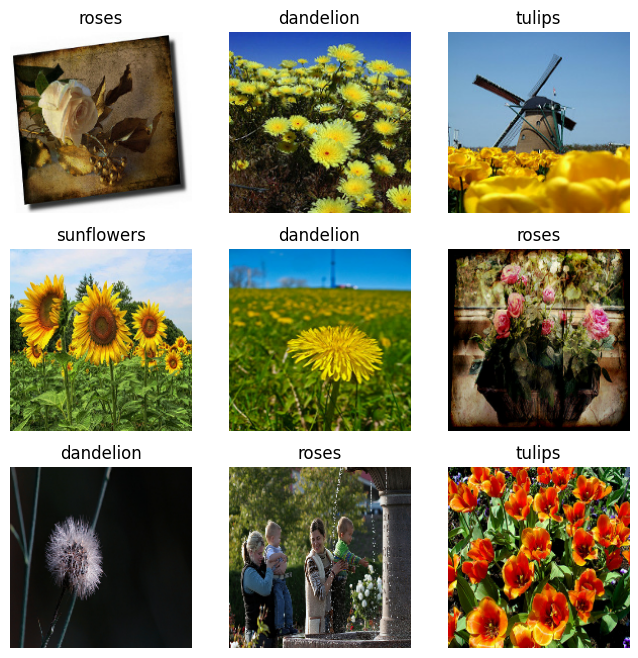

In [20]:
plt.figure(figsize=(8,8))

for images, labels in train_ds.take(1):
    for i in range(9):
        plt.subplot(3,3,i+1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

plt.show()

In [21]:
normalization_layer = layers.Rescaling(1./255)

train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
val_ds = val_ds.map(lambda x, y: (normalization_layer(x), y))

In [22]:
model = keras.Sequential([
    layers.Conv2D(32, 3, activation='relu', input_shape=(180,180,3)),
    layers.MaxPooling2D(),

    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(128, 3, activation='relu'),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(len(class_names), activation='softmax')
])

c:\Users\Aditya.konde\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [23]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [24]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 143s 2s/step - accuracy: 0.3941 - loss: 1.4018 - val_accuracy: 0.5981 - val_loss: 1.0710
Epoch 2/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 93s 971ms/step - accuracy: 0.5998 - loss: 1.0211 - val_accuracy: 0.5940 - val_loss: 0.9785
Epoch 3/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 180s 1s/step - accuracy: 0.6597 - loss: 0.8609 - val_accuracy: 0.6526 - val_loss: 0.8819
Epoch 4/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 123s 1s/step - accuracy: 0.7289 - loss: 0.6994 - val_accuracy: 0.6390 - val_loss: 0.9795
Epoch 5/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 148s 1s/step - accuracy: 0.8048 - loss: 0.5200 - val_accuracy: 0.6526 - val_loss: 1.0984
Epoch 6/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 151s 1s/step - accuracy: 0.8825 - loss: 0.3301 - val_accuracy: 0.6730 - val_loss: 1.1171
Epoch 7/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 100s 1s/step - accuracy: 0.9322 - loss: 0.1997 - val_accuracy: 0.6403 - val_loss: 1.3820
Epoch 8/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 137s 1s/step - accuracy: 0.9496 - loss: 0.1516 - val_accuracy: 0.6281 -

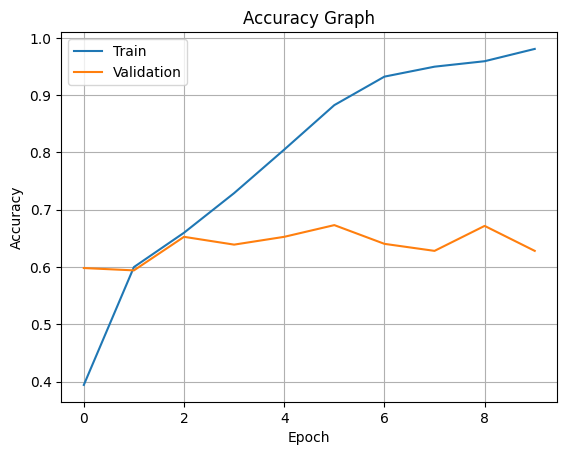

In [25]:
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Accuracy Graph')
plt.legend()
plt.grid(True)

plt.show()

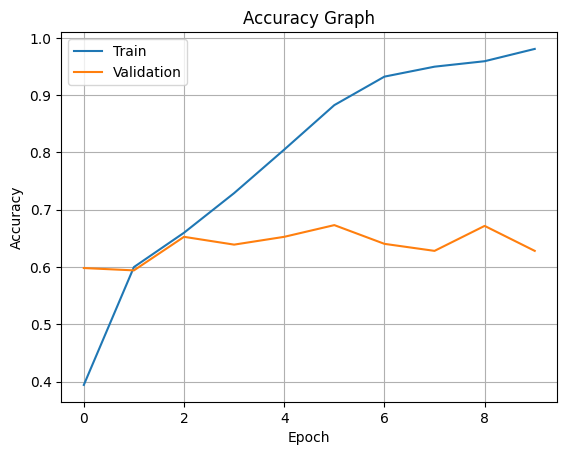

In [26]:
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Accuracy Graph')
plt.legend()
plt.grid(True)

plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 270ms/step


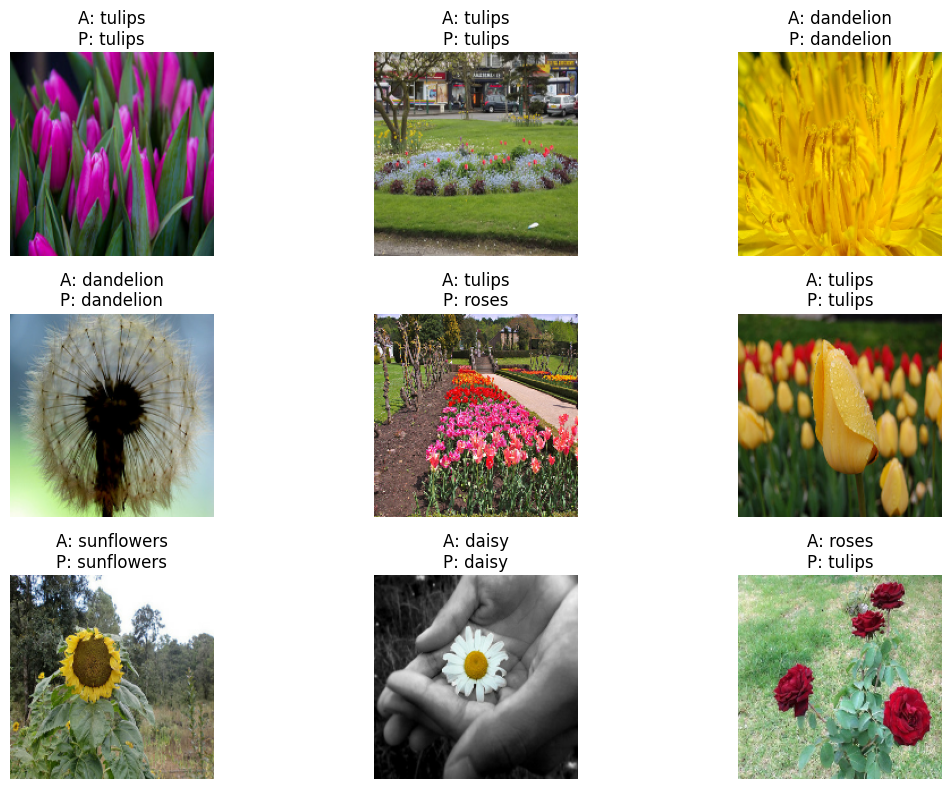

In [28]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(12,8))

for images, labels in val_ds.take(1):
    predictions = model.predict(images)
    
    for i in range(9):
        plt.subplot(3,3,i+1)
        
        img = images[i].numpy()   # ❗ DO NOT convert to uint8
        
        pred_class = np.argmax(predictions[i])
        actual_class = labels[i].numpy()
        
        plt.imshow(img)
        plt.title(f"A: {class_names[actual_class]}\nP: {class_names[pred_class]}")
        plt.axis("off")

plt.tight_layout()
plt.show()